In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi
import sympy as sp

FLOAT32 = np.float32

In [106]:

# ============================
# Parameters
# ============================

SECONDS_PER_YEAR = FLOAT32(365 * 24 * 3600)
### anthropogenic emissions ###
A_tot = FLOAT32(10000.0)   # GtC, total carbon emitted ## default: 5000
t_opt = FLOAT32(250.0)    # yr, t_opt for RCP8.5
t_sink = FLOAT32(t_opt + 1000.0)   # yr, t_sink for RCP8.5

# Symbolic variable
t = sp.symbols("t", real=True)

# Original cumulative emissions
A_old = A_tot * (
    1/(1 + 2.5*sp.exp((t_opt - t)/50))
    - 1/(1 + 2.5*sp.exp(t_opt/50))
)

# New cumulative emissions with sinks
A_new = A_tot * (
    (
        1/(1 + 2.5*sp.exp((t_opt - t)/50))
        - 1/(1 + 2.5*sp.exp(t_opt/50))
    )
    -
    (
        1/(1 + 2.5*sp.exp((t_sink - t)/50))
        - 1/(1 + 2.5*sp.exp(t_sink/50))
    )
)

J_old = sp.diff(A_old, t)
J_new = sp.diff(A_new, t)

J_old_func = sp.lambdify(t, J_old, "numpy")
J_new_func = sp.lambdify(t, J_new, "numpy")

### inital Temperature ###
Ts_init = FLOAT32(0.0)      # K, initial surface temperature
Td_init = FLOAT32(0.0)      # K, initial deep ocean temperature
lam_star = FLOAT32(0.75)       # W m^-2 K^-1, heat transfer coefficient
lam = FLOAT32(1.75)         # W m^-2 K^-1, climate feedback parameter
beta = FLOAT32(5.35)        # W m^-2 K^-1, CO2 forcing parameter


### Heat capacities ###
surface_depth = FLOAT32(50.0)
deep_depth = FLOAT32(3000.0)
c_s = FLOAT32(4000.0) * surface_depth * FLOAT32(1000.0)      # J m^-2 K^-1
c_d = FLOAT32(4000.0) * deep_depth * FLOAT32(1000.0)       # J m^-2 K^-1
c_star = c_s + c_d                     # J m^-2 K^-1

### atmospheric carbon ###
k_a  = FLOAT32(2.12)          # CO2 scaling constant
Ca_init = FLOAT32(600.0)         # GtC, pre-industrial atmospheric carbon
P_a0 = Ca_init / k_a    # ppm, pre-industrial atmospheric CO2

etaH = FLOAT32(0.7)         # W m^-2 K^-1, heat transfer coefficient

### land carbon ###
beta_pi = FLOAT32(0.4)     # CO2 fertilization factor
chi     = FLOAT32(1.8)     # scaling constant
tau_l0   = FLOAT32(41.0)    # yr, lifetime of land carbon
Pi_0    = FLOAT32(60.0)    # GtC/yr, preindustrial land flux
Cl_init    = FLOAT32(2460.0)  # GtC, preindustrial land carbon

### ocean carbon cycle ###
D     = surface_depth + deep_depth     # m, average ocean depth
delta = surface_depth / D    # fraction (mixed-layer depth / D)
gamma = FLOAT32(0.02)        # GtC/yr/ppm, air-sea transfer coefficient
mu_0  = FLOAT32(5.0)        # buffer constant (m/year)
zeta  = 6#10.5        # ratio between ocean reservoirs and atmosphere
etaC = mu_0/D       # transfer rate by total depth

# C_s0 + C_d0 = 6 * zeta * C_a0
# C_s0 / C_d0 = delta / (1 - delta)
# => solve the two simultaneous equations for C_s0, C_d0

total_sd = FLOAT32(6.0) * zeta * Ca_init   # GtC, total preindustrial ocean carbon
Cd_init = (FLOAT32(1.0)-delta) * total_sd   # GtC, preindustrial deep ocean carbon

Cs_init = total_sd - Cd_init               # GtC, preindustrial surface ocean carbon

kappa_o = FLOAT32(6.0) * k_a * delta   # ocean CO2 uptake constant


def box_rhs(t, y, scenario=1):
    """
    scenario=1: source only (J_old) — single sigmoid rise
    scenario=2: source + sink (J_new) — rise then decline
    """
    t = FLOAT32(t)
    Ts, Td, Cs, Cd, Ca, Cl = np.asarray(y, dtype=FLOAT32)

    ### Anthropogenic emissions ###
    if scenario == 1:
        J = FLOAT32(J_old_func(t))
    elif scenario == 2:
        J = FLOAT32(J_new_func(t))
    else:
        raise ValueError("scenario must be 1 or 2")

    ### Temperature evolution surface and deep ###
    forcing = beta * np.log(Ca / Ca_init + FLOAT32(1.0))

    dTs = FLOAT32(
        ((-lam * Ts
        + forcing
        - (etaH + lam_star) * (Ts - Td))
        * SECONDS_PER_YEAR
        / (delta * c_star))
    )

    dTd = FLOAT32(
        (etaH * (Ts - Td)
        * SECONDS_PER_YEAR
        / ((FLOAT32(1.0)-delta) * c_star))
    )

    dCl = FLOAT32(
        Pi_0 * (FLOAT32(1.0) + beta_pi * np.log((Ca / Ca_init) + FLOAT32(1.0)))
        - ((Cl + Cl_init) / tau_l0) * chi ** (Ts / FLOAT32(10.0))
    )

    ### Surface ocean carbon evolution ###

    ko = k_a / zeta * (Cs_init / Ca_init)

    dCs = FLOAT32(gamma * (Ca / k_a - Cs / ko) - etaC * (Cs / delta - Cd / (FLOAT32(1.0)-delta)))

    ### Deep ocean carbon evolution ###

    dCd = FLOAT32(etaC * (Cs / delta - Cd / (FLOAT32(1.0)-delta)))

    ### Atmosphere carbon evolution ###

    dCa = FLOAT32(J - dCs - dCl - dCd)

    return [dTs, dTd, dCs, dCd, dCa, dCl]


In [107]:
t = np.arange(FLOAT32(0.0), FLOAT32(20000.0), FLOAT32(1.0), dtype=FLOAT32)  # time in years

atmo_forcing = FLOAT32(0.0)
solver_kwargs = dict(method='RK45', t_eval=t, rtol=1e-8, atol=1e-10)

# Scenario 1: source only (J_old)
y_box = [FLOAT32(0.0), FLOAT32(0.0), FLOAT32(0.0), FLOAT32(0.0), atmo_forcing, FLOAT32(0.0)]
sol_box_source = spi.solve_ivp(
    lambda t, y: box_rhs(t, y, scenario=1),
    (t[0], t[-1]),
    y_box,
    **solver_kwargs
)

# Scenario 2: source + sink (J_new)
y_box = [FLOAT32(0.0), FLOAT32(0.0), FLOAT32(0.0), FLOAT32(0.0), atmo_forcing, FLOAT32(0.0)]
sol_box_source_sink = spi.solve_ivp(
    lambda t, y: box_rhs(t, y, scenario=2),
    (t[0], t[-1]),
    y_box,
    **solver_kwargs
)


In [108]:
def find_equilibrium_time(t, gradient, tolerance=FLOAT32(1e-3)):
    """
    Finds the first value from behind where the gradient is more than the tolerance
    and then returns the corresponding time. If no such value is found, returns None.
    """
    t = np.asarray(t, dtype=FLOAT32)
    gradient = np.asarray(gradient, dtype=FLOAT32)
    for i in range(len(gradient) - 1, -1, -1):
        if abs(gradient[i]) > tolerance:
            return t[i]  # return time in years
    return None

# Compute gradients (dy/dt) by re-evaluating box_rhs at each stored time step.
# This gives exact ODE derivatives, shape (6, N), matching sol.y.
def compute_gradients(sol, scenario):
    grads = np.array(
        [box_rhs(ti, yi, scenario=scenario) for ti, yi in zip(sol.t, sol.y.T)],
        dtype=FLOAT32,
    )
    return grads.T  # shape: (n_vars, n_timepoints)

grad_s1 = compute_gradients(sol_box_source, scenario=1)
grad_s2 = compute_gradients(sol_box_source_sink, scenario=2)

find_equilibrium_time(t, grad_s1[2], tolerance=FLOAT32(1e-3))
find_equilibrium_time(t, grad_s2[2], tolerance=FLOAT32(1e-3))


np.float32(4170.0)

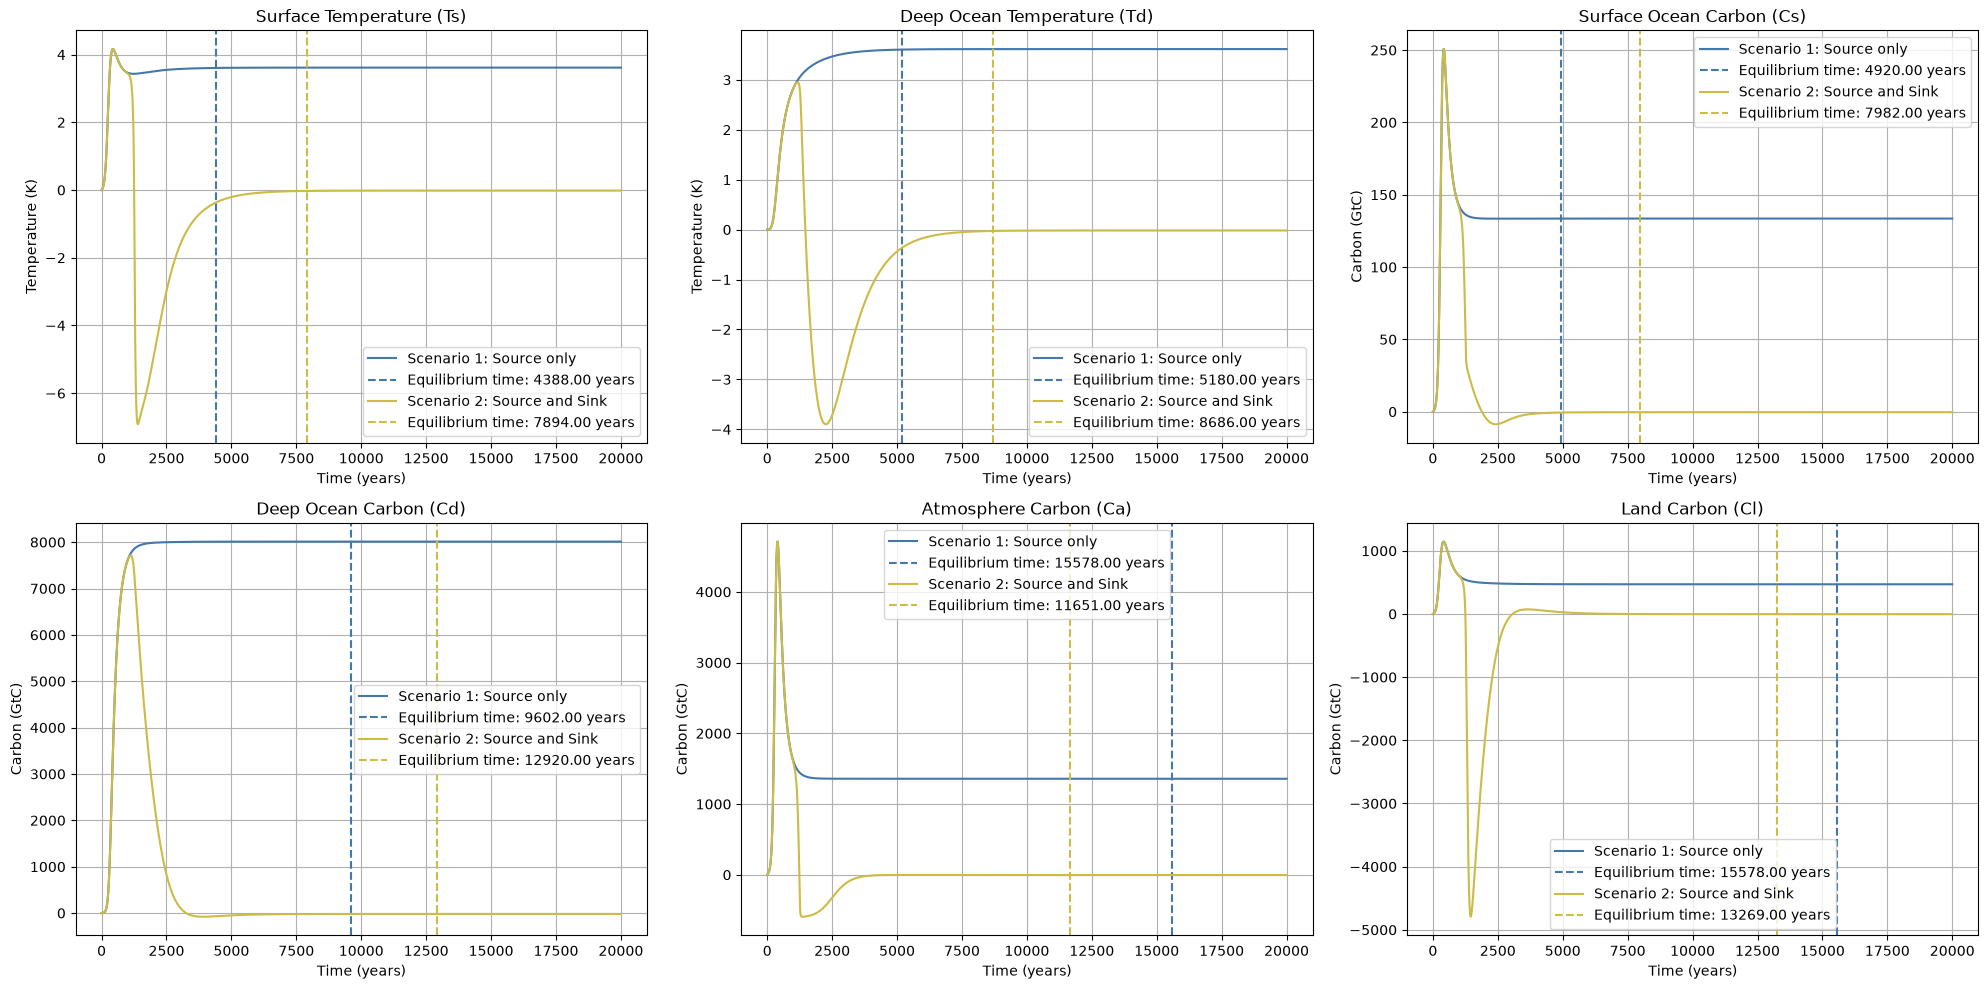

In [109]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
axs = axs.flatten()

titles = [
    'Surface Temperature (Ts)', 'Deep Ocean Temperature (Td)',
    'Surface Ocean Carbon (Cs)', 'Deep Ocean Carbon (Cd)',
    'Atmosphere Carbon (Ca)', 'Land Carbon (Cl)'
]
ylabels = ['Temperature (K)', 'Temperature (K)', 'Carbon (GtC)', 'Carbon (GtC)', 'Carbon (GtC)', 'Carbon (GtC)']

time32 = np.asarray(t, dtype=FLOAT32)

for sol, grad, color, label in [
    (sol_box_source, grad_s1, '#4477AA',  'Scenario 1: Source only'),
    (sol_box_source_sink, grad_s2, '#CCBB44', 'Scenario 2: Source and Sink')
    ]:
    sol_t = np.asarray(sol.t, dtype=FLOAT32)
    sol_y = np.asarray(sol.y, dtype=FLOAT32)
    for i in range(sol_y.shape[0]):
        axs[i].plot(sol_t, sol_y[i], label=label, color=color)
        final_value = np.cumsum(np.asarray(grad[i], dtype=FLOAT32), dtype=FLOAT32)[-1]  # Get the final value of the cumulative sum
        equlibrium_time = find_equilibrium_time(sol_t, grad[i], tolerance=FLOAT32(FLOAT32(1e-5)))  # Adjust tolerance based on final value
        if equlibrium_time is not None:
            axs[i].axvline(x=equlibrium_time, color=color, linestyle='--', label=f'Equilibrium time: {equlibrium_time:.2f} years')

for i, ax in enumerate(axs):
    ax.set_xlabel('Time (years)')
    ax.set_ylabel(ylabels[i])
    ax.set_title(titles[i])
    ax.grid()
    ax.legend()

plt.tight_layout()
plt.show()

/var/folders/yg/kc1tdyyx1jn7mbgy7k9hm4x80000gn/T/ipykernel_84818/4186665589.py:15: RuntimeWarning: overflow encountered in exp
  1/(1 + 2.5*np.exp((t_sink - t)/50))
/var/folders/yg/kc1tdyyx1jn7mbgy7k9hm4x80000gn/T/ipykernel_84818/4186665589.py:15: RuntimeWarning: overflow encountered in multiply
  1/(1 + 2.5*np.exp((t_sink - t)/50))
/var/folders/yg/kc1tdyyx1jn7mbgy7k9hm4x80000gn/T/ipykernel_84818/4186665589.py:16: RuntimeWarning: overflow encountered in exp
  - 1/(1 + 2.5*np.exp(t_sink/50))


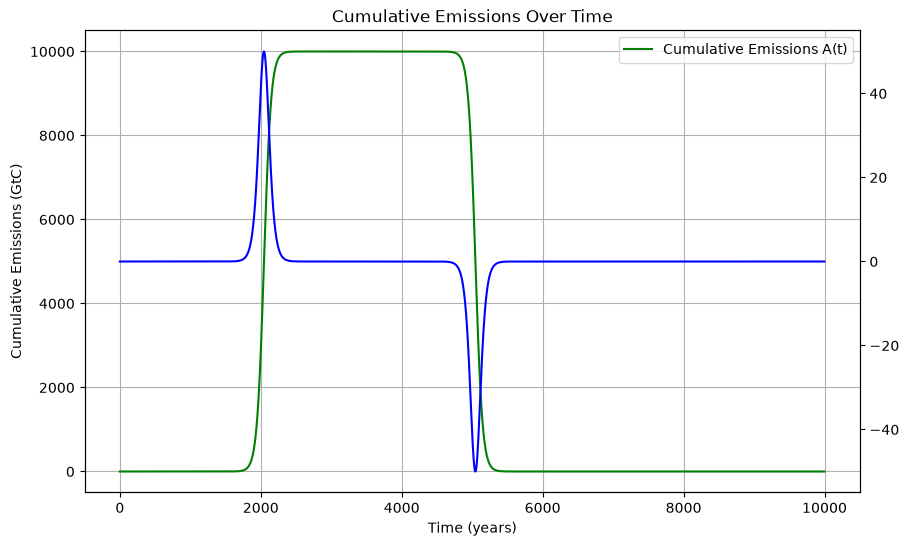

In [110]:
### anthropogenic emissions ###
A_tot = FLOAT32(10000.0)   # GtC, total carbon emitted
t_opt = FLOAT32(2000.0)    # yr, t_opt for RCP8.5
t_sink = FLOAT32(5000.0)    # yr, t_sink for RCP8.5

def A(t):
    t = np.asarray(t, dtype=FLOAT32)

    rise = (
        1/(1 + 2.5*np.exp((t_opt - t)/50))
        - 1/(1 + 2.5*np.exp(t_opt/50))
    )

    decline = (
        1/(1 + 2.5*np.exp((t_sink - t)/50))
        - 1/(1 + 2.5*np.exp(t_sink/50))
    )

    return A_tot * (rise - decline)

fig, ax = plt.subplots(figsize=(10, 6))
t = np.arange(FLOAT32(0.0), FLOAT32(10000.0), FLOAT32(1.0), dtype=FLOAT32) # time in years
A_test = A(t)
J = np.diff(A_test)
ax.plot(t[:-1], A_test[:-1], label='Cumulative Emissions A(t)', color='green')
ax.twinx().plot(t[:-1], J, label='Cumulative Emissions A(t)', color='blue')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Cumulative Emissions (GtC)')
ax.set_title('Cumulative Emissions Over Time')
ax.grid()
ax.legend()


In [ ]:
def box_rhs(t, y, scenario=1):
    """
    scenario=1: source only (J_old) — single sigmoid rise
    scenario=2: source + sink (J_new) — rise then decline
    """
    t = FLOAT32(t)
    Ts, Td, Cs, Cd, Ca, Cl = np.asarray(y, dtype=FLOAT32)

    # Calculate actual absolute carbon masses in the reservoirs
    total_Ca = Ca + Ca_init
    total_Cl = Cl + Cl_init
    total_Cs = Cs + Cs_init
    total_Cd = Cd + Cd_init

    ### Anthropogenic emissions & Dynamic Sink Throttling ###
    if scenario == 1:
        J = FLOAT32(J_old_func(t))
    elif scenario == 2:
        J_prescribed = FLOAT32(J_new_func(t))

        # Throttle the engineered sink only if absolute atmospheric carbon
        # is running completely empty (approaching absolute 0, not pre-industrial)
        if J_prescribed < 0:
            throttling_factor = np.clip(total_Ca / FLOAT32(100.0), 0.0, 1.0)
            J = J_prescribed * throttling_factor
        else:
            J = J_prescribed
    else:
        raise ValueError("scenario must be 1 or 2")

    ### Temperature evolution surface and deep ###
    # Protect log: total_Ca / Ca_init must be strictly positive.
    # If Ca drops below 0 (but stays above -Ca_init), total_Ca/Ca_init is between 0 and 1,
    # making the log negative, which correctly models cooling below baseline!
    log_arg_temp = np.maximum(total_Ca / Ca_init, FLOAT32(1e-5))
    forcing = beta * np.log(log_arg_temp)

    dTs = FLOAT32(
        ((-lam * Ts
        + forcing
        - (etaH + lam_star) * (Ts - Td))
        * SECONDS_PER_YEAR
        / (delta * c_star))
    )

    dTd = FLOAT32(
        (etaH * (Ts - Td)
        * SECONDS_PER_YEAR
        / ((FLOAT32(1.0)-delta) * c_star))
    )

    ### Land carbon evolution ###
    log_arg_land = np.maximum(total_Ca / Ca_init, FLOAT32(1e-5))

    dCl = FLOAT32(
        Pi_0 * (FLOAT32(1.0) + beta_pi * np.log(log_arg_land))
        - (total_Cl / tau_l0) * chi ** (Ts / FLOAT32(10.0))
    )

    # PHYSICAL FLOOR: Total land carbon cannot drop below 0 (Ca can go down to -Cl_init)
    if total_Cl <= 0.0 and dCl < 0:
        dCl = FLOAT32(0.0)

    ### Surface ocean carbon evolution ###
    ko = k_a / zeta * (Cs_init / Ca_init)
    dCs = FLOAT32(gamma * (Ca / k_a - Cs / ko) - etaC * (Cs / delta - Cd / (FLOAT32(1.0)-delta)))

    # PHYSICAL FLOOR: Total surface ocean carbon cannot drop below 0
    if total_Cs <= 0.0 and dCs < 0:
        dCs = FLOAT32(0.0)

    ### Deep ocean carbon evolution ###
    dCd = FLOAT32(etaC * (Cs / delta - Cd / (FLOAT32(1.0)-delta)))

    # PHYSICAL FLOOR: Total deep ocean carbon cannot drop below 0
    if total_Cd <= 0.0 and dCd < 0:
        dCd = FLOAT32(0.0)

    ### Atmosphere carbon evolution ###
    dCa = FLOAT32(J - dCs - dCl - dCd)

    # PHYSICAL FLOOR: Total atmosphere carbon cannot drop below 0 (Ca can go down to -Ca_init)
    if total_Ca <= 0.0 and dCa < 0:
        dCa = FLOAT32(0.0)

    return [dTs, dTd, dCs, dCd, dCa, dCl]

In [8]:
t = np.arange(FLOAT32(0.0), FLOAT32(20000.0), FLOAT32(1.0), dtype=FLOAT32)  # time in years

atmo_forcing = FLOAT32(0.0)
solver_kwargs = dict(method='RK45', t_eval=t, rtol=1e-8, atol=1e-10)

# Scenario 1: source only (J_old)
y_box = [FLOAT32(0.0), FLOAT32(0.0), FLOAT32(0.0), FLOAT32(0.0), atmo_forcing, FLOAT32(0.0)]
sol_box_source = spi.solve_ivp(
    lambda t, y: box_rhs(t, y, scenario=1),
    (t[0], t[-1]),
    y_box,
    **solver_kwargs
)

# Scenario 2: source + sink (J_new)
y_box = [FLOAT32(0.0), FLOAT32(0.0), FLOAT32(0.0), FLOAT32(0.0), atmo_forcing, FLOAT32(0.0)]
sol_box_source_sink = spi.solve_ivp(
    lambda t, y: box_rhs(t, y, scenario=2),
    (t[0], t[-1]),
    y_box,
    **solver_kwargs
)


In [9]:
def find_equilibrium_time(t, gradient, tolerance=FLOAT32(1e-3)):
    """
    Finds the first value from behind where the gradient is more than the tolerance
    and then returns the corresponding time. If no such value is found, returns None.
    """
    t = np.asarray(t, dtype=FLOAT32)
    gradient = np.asarray(gradient, dtype=FLOAT32)
    for i in range(len(gradient) - 1, -1, -1):
        if abs(gradient[i]) > tolerance:
            return t[i]  # return time in years
    return None

# Compute gradients (dy/dt) by re-evaluating box_rhs at each stored time step.
# This gives exact ODE derivatives, shape (6, N), matching sol.y.
def compute_gradients(sol, scenario):
    grads = np.array(
        [box_rhs(ti, yi, scenario=scenario) for ti, yi in zip(sol.t, sol.y.T)],
        dtype=FLOAT32,
    )
    return grads.T  # shape: (n_vars, n_timepoints)

grad_s1 = compute_gradients(sol_box_source, scenario=1)
grad_s2 = compute_gradients(sol_box_source_sink, scenario=2)

find_equilibrium_time(t, grad_s1[2], tolerance=FLOAT32(1e-3))
find_equilibrium_time(t, grad_s2[2], tolerance=FLOAT32(1e-3))


np.float32(3443.0)

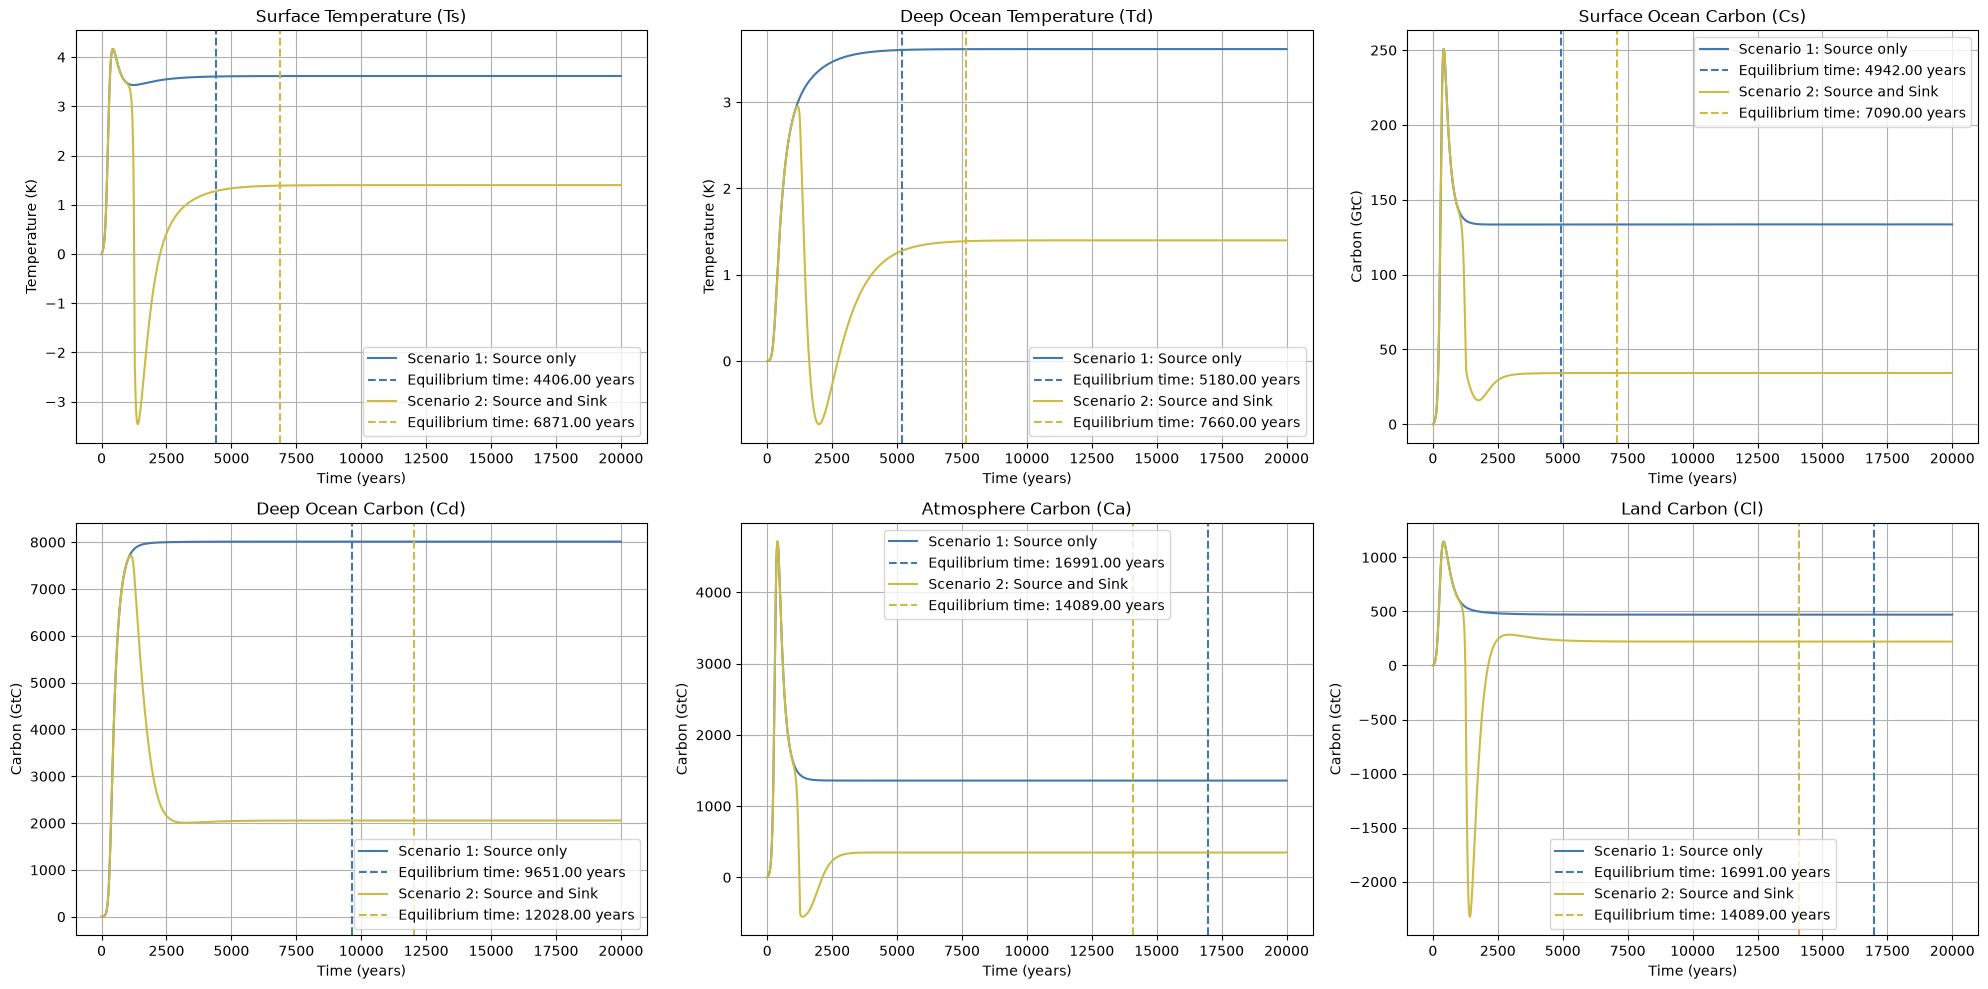

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
axs = axs.flatten()

titles = [
    'Surface Temperature (Ts)', 'Deep Ocean Temperature (Td)',
    'Surface Ocean Carbon (Cs)', 'Deep Ocean Carbon (Cd)',
    'Atmosphere Carbon (Ca)', 'Land Carbon (Cl)'
]
ylabels = ['Temperature (K)', 'Temperature (K)', 'Carbon (GtC)', 'Carbon (GtC)', 'Carbon (GtC)', 'Carbon (GtC)']

time32 = np.asarray(t, dtype=FLOAT32)

for sol, grad, color, label in [
    (sol_box_source, grad_s1, '#4477AA',  'Scenario 1: Source only'),
    (sol_box_source_sink, grad_s2, '#CCBB44', 'Scenario 2: Source and Sink')
    ]:
    sol_t = np.asarray(sol.t, dtype=FLOAT32)
    sol_y = np.asarray(sol.y, dtype=FLOAT32)
    for i in range(sol_y.shape[0]):
        axs[i].plot(sol_t, sol_y[i], label=label, color=color)
        final_value = np.cumsum(np.asarray(grad[i], dtype=FLOAT32), dtype=FLOAT32)[-1]  # Get the final value of the cumulative sum
        equlibrium_time = find_equilibrium_time(sol_t, grad[i], tolerance=FLOAT32(FLOAT32(1e-5)))  # Adjust tolerance based on final value
        if equlibrium_time is not None:
            axs[i].axvline(x=equlibrium_time, color=color, linestyle='--', label=f'Equilibrium time: {equlibrium_time:.2f} years')

for i, ax in enumerate(axs):
    ax.set_xlabel('Time (years)')
    ax.set_ylabel(ylabels[i])
    ax.set_title(titles[i])
    ax.grid()
    ax.legend()

plt.tight_layout()
plt.show()